# 01 · Validación de los grafos ICE

Verifica fuente, región, conectividad, pesos y óptimo exacto de G6, G8, G10
y G12. Los grafos oficiales se conservan sin inventar aristas.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(
    ruta for ruta in [Path.cwd(), Path.cwd().parent]
    if (ruta / "config.yaml").exists()
)
TAMANOS = (6, 8, 10, 12)


In [2]:
def cargar_grafo(n):
    nodos = pd.read_csv(ROOT / "datos" / "grafos" / f"grafo_{n}_nodos.csv")
    aristas = pd.read_csv(ROOT / "datos" / "grafos" / f"grafo_{n}_aristas.csv")
    G = nx.Graph()
    for _, fila in nodos.iterrows():
        G.add_node(str(fila["node_id"]), **fila.to_dict())
    for _, fila in aristas.iterrows():
        G.add_edge(
            str(fila["source_id"]),
            str(fila["target_id"]),
            weight=float(fila["weight"]),
        )
    return G, nodos, aristas

grafos = {}
filas = []
for n in TAMANOS:
    G, nodos, aristas = cargar_grafo(n)
    grafos[n] = G
    pesos = [d["weight"] for _, _, d in G.edges(data=True)]
    filas.append({
        "n": n,
        "nodos": G.number_of_nodes(),
        "aristas": G.number_of_edges(),
        "region": ", ".join(sorted(set(nodos["region"]))),
        "conectado": nx.is_connected(G),
        "arbol": nx.is_tree(G),
        "bipartito": nx.is_bipartite(G),
        "pesos_positivos": all(p > 0 for p in pesos),
        "peso_total": sum(pesos),
    })

df_validacion = pd.DataFrame(filas)
display(df_validacion)
assert (df_validacion["nodos"] == df_validacion["n"]).all()
assert df_validacion["conectado"].all()
assert df_validacion["pesos_positivos"].all()
assert df_validacion["region"].eq("Central").all()


,n,nodos,aristas,region,conectado,arbol,bipartito,pesos_positivos,peso_total
0,6,6,5,Central,True,True,True,True,38.301790
1,8,8,7,Central,True,True,True,True,42.218037
2,10,10,9,Central,True,True,True,True,87.075048
3,12,12,11,Central,True,True,True,True,93.299621


## Óptimo exacto y limitación estructural

Como las cuatro instancias son árboles bipartitos con pesos positivos, todas
sus aristas pueden cortarse. Por eso el óptimo coincide con el peso total.
Esto se reporta como limitación; no se altera la red para hacerla artificialmente
difícil.

In [3]:
def valor_corte(G, nodos, bits):
    asignacion = dict(zip(nodos, bits))
    return sum(
        d["weight"] for u, v, d in G.edges(data=True)
        if asignacion[u] != asignacion[v]
    )

def maxcut_exacto(G):
    nodos = sorted(G.nodes())
    mejor = -np.inf
    mejores = []
    for mascara in range(2 ** (len(nodos) - 1)):
        bits = [0] + [
            (mascara >> (i - 1)) & 1 for i in range(1, len(nodos))
        ]
        costo = valor_corte(G, nodos, bits)
        bitstring = "".join(map(str, bits))
        if costo > mejor + 1e-9:
            mejor, mejores = costo, [bitstring]
        elif np.isclose(costo, mejor):
            mejores.append(bitstring)
    return mejor, mejores

exactos = []
for n, G in grafos.items():
    optimo, soluciones = maxcut_exacto(G)
    exactos.append({
        "n": n,
        "optimo_exacto": optimo,
        "peso_total": G.size(weight="weight"),
        "razon_optimo_peso": optimo / G.size(weight="weight"),
        "soluciones_sin_complementos": len(soluciones),
        "ejemplo": soluciones[0],
    })
df_exactos = pd.DataFrame(exactos)
display(df_exactos)
assert np.allclose(df_exactos["optimo_exacto"], df_exactos["peso_total"])


,n,optimo_exacto,peso_total,razon_optimo_peso,soluciones_sin_complementos,ejemplo
0,6,38.301790,38.301790,1.0,1,011101
1,8,42.218037,42.218037,1.0,1,00101101
2,10,87.075048,87.075048,1.0,1,0011010101
3,12,93.299621,93.299621,1.0,1,000110110101


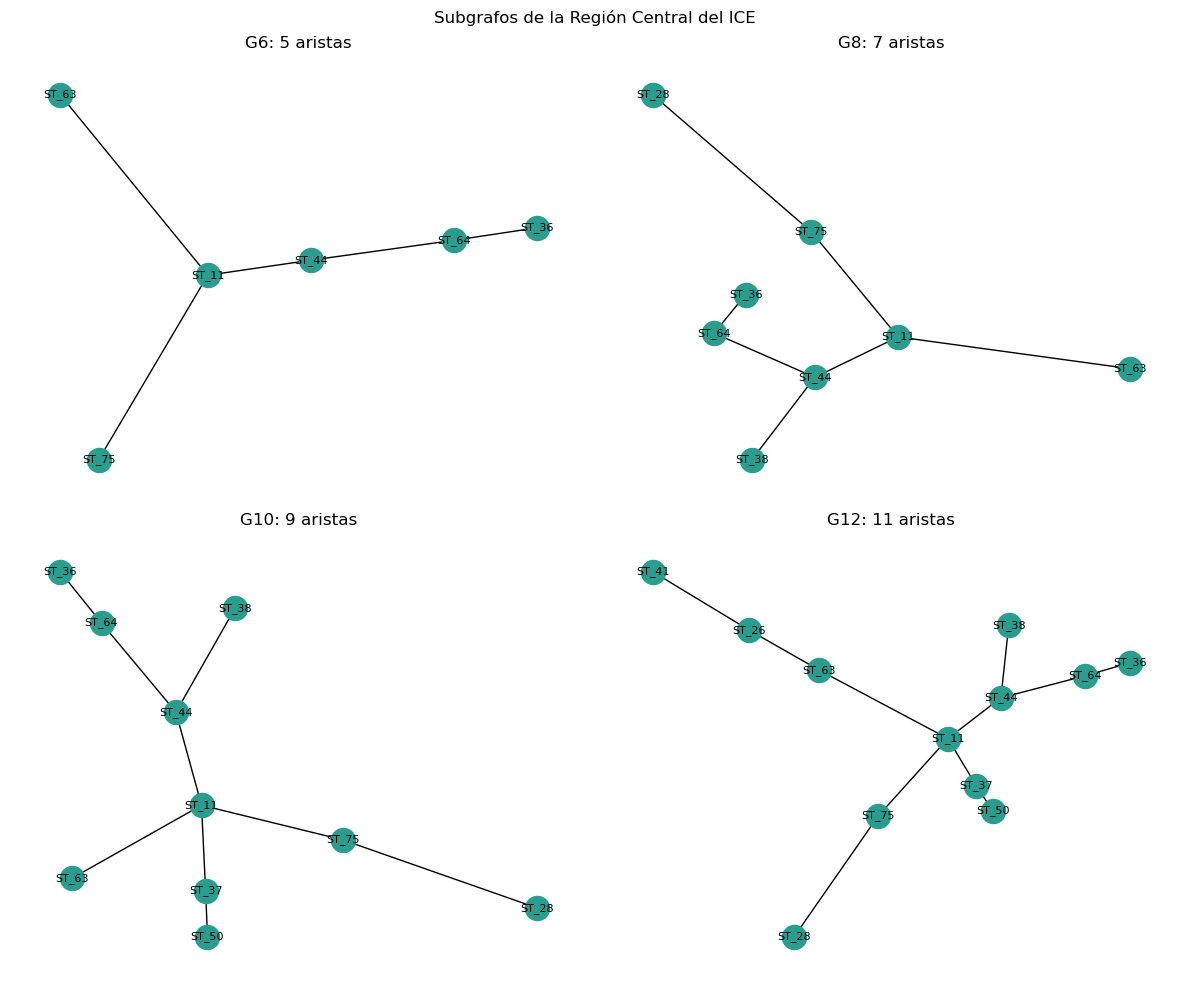

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (n, G) in zip(axes.flat, grafos.items()):
    pos = nx.spring_layout(G, seed=2026, weight="weight")
    nx.draw_networkx(G, pos, ax=ax, node_color="#2A9D8F", font_size=8)
    ax.set_title(f"G{n}: {G.number_of_edges()} aristas")
    ax.axis("off")
plt.suptitle("Subgrafos de la Región Central del ICE")
plt.tight_layout()
plt.show()
